## Comment utiliser ce notebook
Cliquer sur une cellule et presser Entrée pour éditer une cellule.<br/>
Appuyer sur Shift+Entrée pour exécuter la cellule.<br/>
Pour répondre à un exercice, remplacer la ligne
```python
# <- completer ici
```
par votre code et exécuter la cellule.
<hr/>

### Seaborn

La librairie [Seaborn](https://seaborn.pydata.org/) est une librairie de visualisation de graphiques statistiques construite sur Matplotlib.

Sous-sections :
[Présentation](#principe)&nbsp;|
[Visualisation de distributions](#distributions)&nbsp;|
[Visualisation de relations](#relations)&nbsp;|
[Exercices](#exercices)&nbsp;

<a id="distributions"></a>
### Présentation

Le but de seaborn est de fournir des fonctions pour produire rapidement les principaux types de graphiques statistiques (distributionnels, relationnels) à partir d'une DataFrame Pandas. 


Dans la suite, nous illustrerons les fonctionnalités de Seaborn sur les jeux de données `Breast Cancer Wisconsin` et `Iris` 

In [1]:
import pandas as pd
import seaborn as sns

features = ['id', 'clump', 'uniformity_cell_size', 'uniformity_cell_shape', 'marginal_adhesion','single_epithelial_cell_size', 'bare_nuclei', 'chromatin', 'normal_nucleoli', 'mitoses']
cls_att = 'class'
breast = pd.read_csv('../data/breast-cancer-wisconsin.data.with_null',names=features+[cls_att])
breast = breast.set_index('id')
breast = breast.dropna()

iris = sns.load_dataset('iris')

__Couleurs__

La fonction `color_palette` permet d'accéder aux [palettes de couleur](https://seaborn.pydata.org/tutorial/color_palettes.html) :

In [2]:
palette = sns.color_palette('Paired')
list(palette)

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [3]:
palette

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [4]:
sns.color_palette('icefire')

[(0.33355526, 0.64107876, 0.80445484),
 (0.28708711, 0.32912157, 0.69034504),
 (0.15652427, 0.15348248, 0.22238175),
 (0.22994394, 0.13076731, 0.15146314),
 (0.61319563, 0.1824336, 0.2687872),
 (0.91463791, 0.43668557, 0.21367954)]

__Thèmes__

Il y a 5 [thèmes prédéfinis](https://seaborn.pydata.org/tutorial/aesthetics.html) : `darkgrid`, `whitegrid`, `dark`, `white`, et `ticks` :

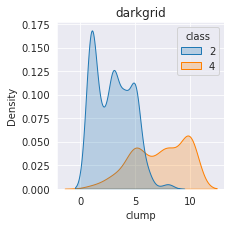

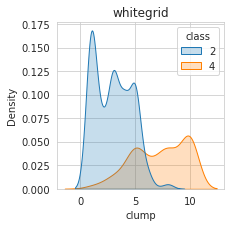

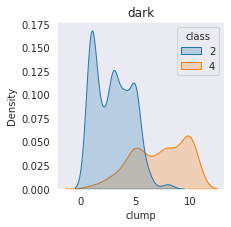

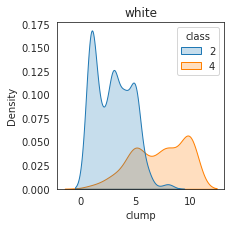

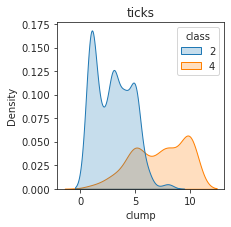

In [5]:
import matplotlib.pyplot as plt
colors = sns.color_palette('Paired')
(blue,orange) = (colors[1],colors[7])
for theme in ['darkgrid','whitegrid','dark','white','ticks']:
    with sns.axes_style(theme):
        plt.figure(figsize=(3,3),dpi=72)
        sns.kdeplot(breast,x='clump', hue='class', fill=True, palette=[blue,orange])
        plt.title(theme)
        plt.show()


__Interface fonctionnelle vs objet__

Le module `seaborn` propose :
- une __interface fonctionnelle__, qui contient une fonction pour chaque type de graphique :`displot()` pour les histogrammes, `boxplot()` pour les boîtes à moustache, `relplot()` pour les relations entre variables, etc.

<Axes: xlabel='clump', ylabel='Density'>

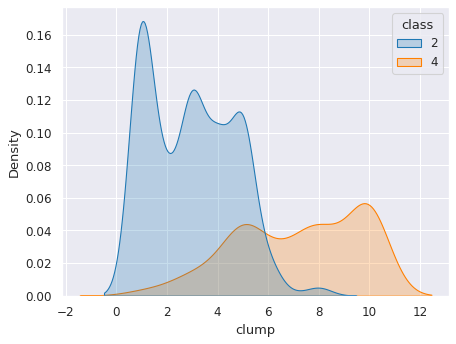

In [6]:
sns.set_theme(rc={'figure.figsize':(6.4,4.8),'figure.dpi':78})
sns.set_style('darkgrid')
sns.kdeplot(breast,x='clump', hue='class', fill=True, palette=[blue,orange])

- une __interface orientée objet__ (expérimentale), qui permet de faire la même chose en [manipulant des objets](https://seaborn.pydata.org/tutorial/objects_interface.html). Dans ce cas on crée d'abord un objet de type `Plot`, qui représente un graphique et est lié à une DataFrame Pandas, et ensuite on lui ajoute différentes couches de visualisation.

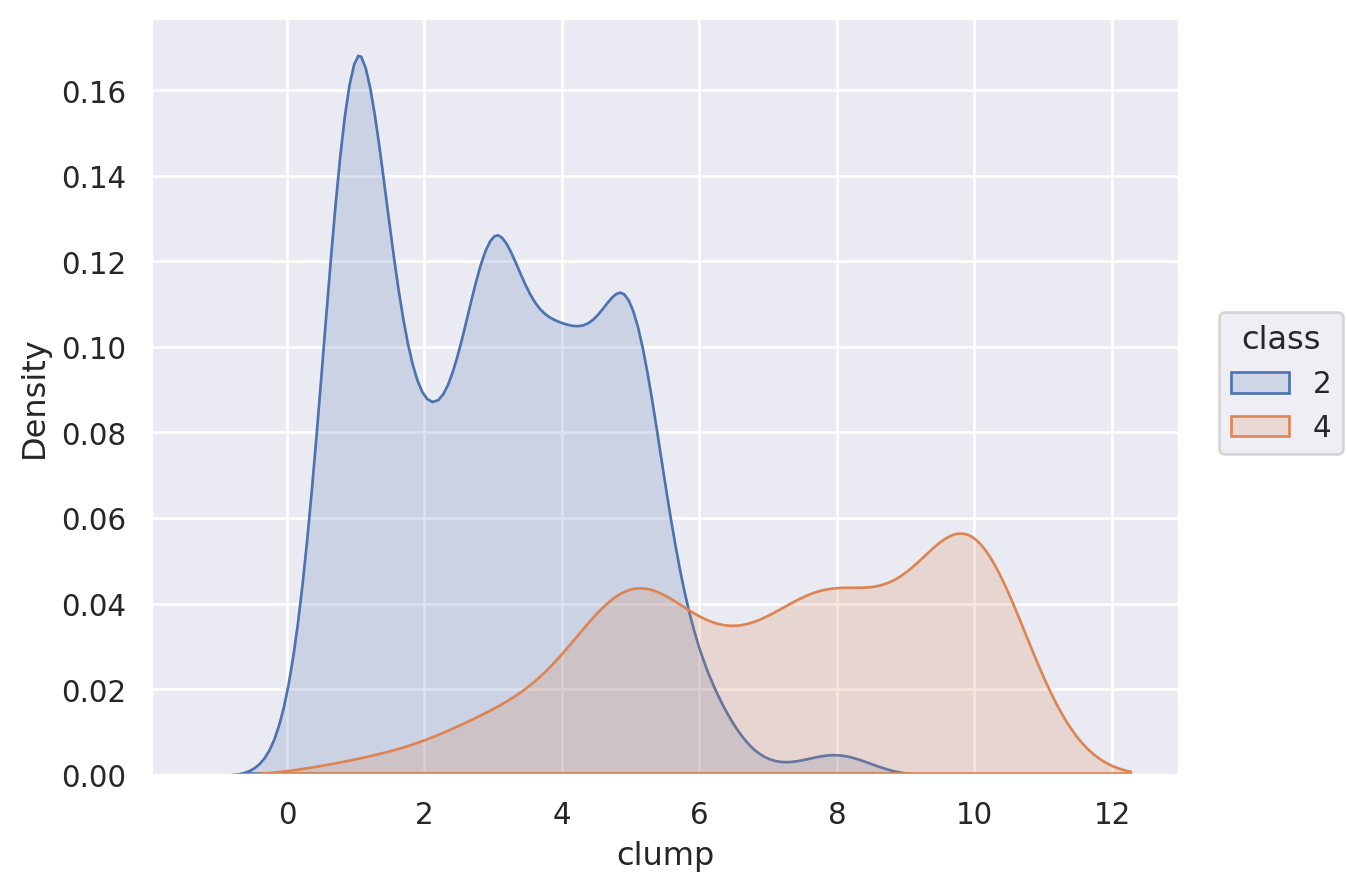

In [7]:
import seaborn.objects as so
sns.set_palette([blue,orange])
df_ = breast.copy()
df_['class'] = breast['class'].values.astype(str)
plot = so.Plot(df_, x='clump', color='class').label(y='Density')
plot.add(so.Area(),so.KDE())

<a id="distributions"></a>
### Visualisation de distributions

Seaborn propose pour visualiser des distributions de données :
- les fonctions `histplot`, `kdeplot`, `ecdfplot` et `rugplot` pour créer des sous-figures (histogrammes, estimation de densité, proportions cumulatives, etc.) ;
- les fonctions `displot`, `jointplot` et `pairplot` pour combiner ces sous-figures dans  des figures plus complexes qui intègrent plusieurs vues sur un même jeu de données.

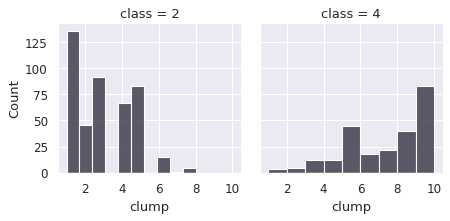

In [8]:
import seaborn as sns
colors = sns.color_palette('icefire')
g = sns.FacetGrid(breast,col='class')
g.map(sns.histplot,'clump',color=colors[2])

<Axes: xlabel='clump', ylabel='Proportion'>

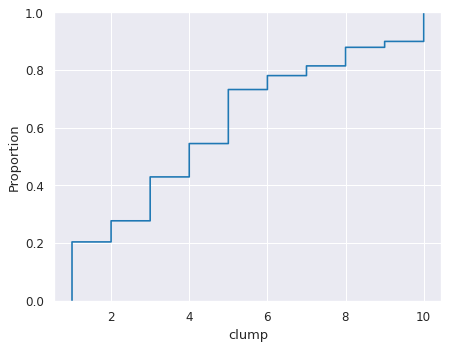

In [9]:
sns.ecdfplot(data=breast,x='clump')

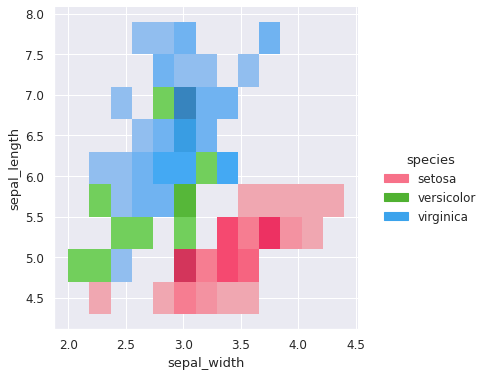

In [10]:
sns.displot(iris,x='sepal_width',y='sepal_length',hue='species')

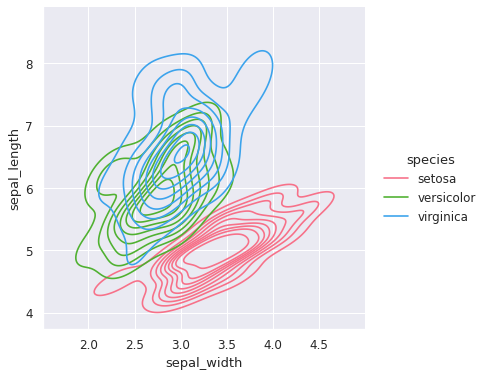

In [11]:
sns.displot(iris,x='sepal_width',y='sepal_length',hue='species', kind='kde')

<a id="relations"></a>
### Visualisation de relations

Au niveau figure, 
Seaborn propose deux fonctions génériques selon le type des variables : 
- `relplot` pour visualiser des [relations statistiques](https://seaborn.pydata.org/tutorial/relational.html) entre __deux variables numériques__
- `catplot` pour visualiser des [distributions par catégorie](https://seaborn.pydata.org/tutorial/categorical.html) si __au moins une des variables est catégorielle__

__Relations statistiques__

Pour visualiser des relations statistiques on peut utiliser :
- le fonction `scatterplot` (nuage de points) 
- la fonction `lineplot` (courbes d'évolution) 

Ces fonctions permettent de créer des sous-figures.

Au niveau figure, la fonction générique `relplot` rassemble ces deux fonctions en une même interface.

Par exemple 
```python
relplot(..., kind='scatter')
``` 
au niveau figure appellera la fonction `scatterplot` pour créer une sous-figure.

Par exemple :

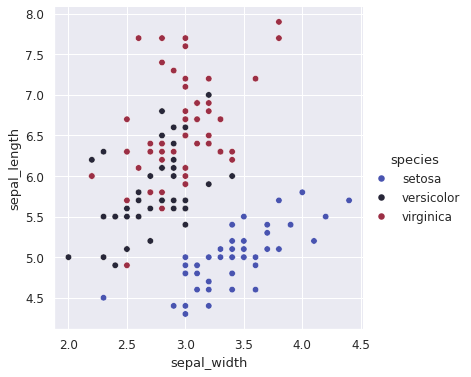

In [12]:
with sns.color_palette('icefire') as c:
    sns.relplot(data=iris,x='sepal_width',y='sepal_length',hue='species',palette=[c[1],c[2],c[4]], kind='scatter')

<Axes: >

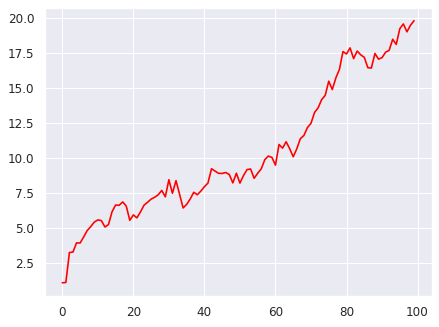

In [13]:
import numpy as np
sns.lineplot(np.cumsum(np.random.normal(0.3, 0.6, size=100)),color='red')

Plusieurs diagrammes en ligne peuvent être aggrégés sur une même figure.

On représente alors la moyenne et l'écart type des lignes obtenues.

Par exemple ici on aggrège 10 diagrammes (fold C0 à C9) :

In [14]:
N = 10
series = np.cumsum(np.random.normal(0.3, 0.6, size=(N,100)),axis=1) 
vals = pd.concat([pd.concat((pd.DataFrame(data=series[i],columns=['val']),pd.DataFrame(['C'+str(i)]*100,columns=['fold'])),axis=1) for i in range(N)],axis=0)
vals = vals.reset_index(names='x')
vals

,x,val,fold
0,0,-0.657795,C0
1,1,-0.348494,C0
2,2,-0.036114,C0
3,3,0.776224,C0
4,4,0.944720,C0
...,...,...,...
995,95,30.984634,C9
996,96,31.505515,C9
997,97,32.444434,C9
998,98,31.900579,C9


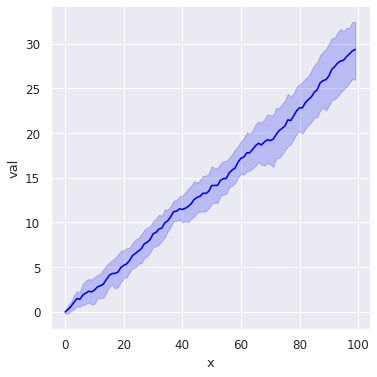

In [15]:
sns.relplot(data=vals,x='x', y='val',  kind='line', color='blue')

__Distributions par catégorie__

Pour visualiser des [distributions par catégorie](https://seaborn.pydata.org/tutorial/categorical.html) on peut utiliser :
- le fonction `stripplot` (dessine un nuage de points par catégorie) 
- la fonction `boxplot` (boites à moustache)
- la fonction `barplot` (histogramme)
- etc. 

Ces fonctions permettent de créer des sous-figures.

Au niveau figure, la fonction générique `catplot` rassemble ces fonctions en une même interface.

Par exemple 
```python
catplot(..., kind='bar')
``` 
au niveau figure appellera la fonction `barplot` pour créer une sous-figure.

Par exemple :

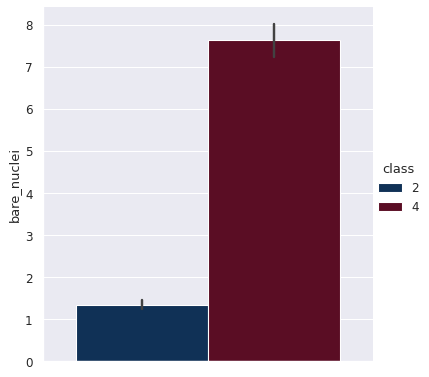

In [16]:
sns.catplot(breast,y='bare_nuclei', hue='class', kind='bar', palette='RdBu_r')

<Axes: ylabel='chromatin'>

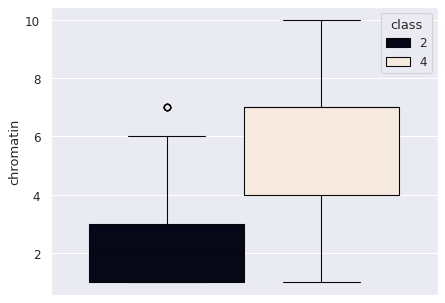

In [17]:
sns.boxplot(breast,y='chromatin',hue='class',palette='rocket')

<Axes: ylabel='chromatin'>

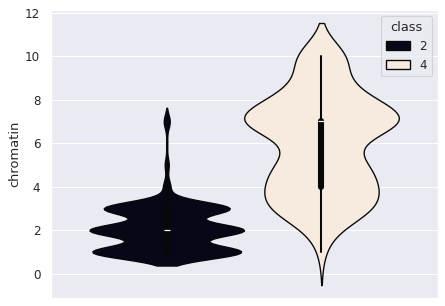

In [18]:
sns.violinplot(breast,y='chromatin',hue='class',palette='rocket')

<a id='exercices'></a>
###  Exercices


Dans le jeu de données Iris, 
on veut chercher (et visualiser) des corrélations (linéaires) entre variables numériques.
Par exemple, on veut chercher des dépendances de la forme "plus la largeur du pétale augmente, plus sa longueur augmente".

Pour cela, on calcule le [coefficient de corrélation de Pearson](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient) pour chaque couple de variables prises 2 à 2.

Le coefficient de Pearson est un nombre entre -1 et 1 qui mesure la dépendances linéaire entre deux variables `X` et `Y` :
- 1 : plus `X` augmente, plus `Y` augmente, 
- -1 : plus `X` augmente, moins `Y` augmente,
- 0 : pas de corrélation linéaire

Par exemple, si on prend les deux séries `petal_length` et `petal_width` suivantes :

In [19]:
petal_series = iris.loc[:,['petal_length','petal_width']].T
petal_series

,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
petal_length,1.4,1.4,1.3,1.5,1.4,1.7,1.4,1.5,1.4,1.5,...,5.6,5.1,5.1,5.9,5.7,5.2,5.0,5.2,5.4,5.1
petal_width,0.2,0.2,0.2,0.2,0.2,0.4,0.3,0.2,0.2,0.1,...,2.4,2.3,1.9,2.3,2.5,2.3,1.9,2.0,2.3,1.8


la fonction [`corrcoef`](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html#numpy.corrcoef) de NumPy permet de calculer les corrélations entre les séries de données prises 2 à 2 :

In [20]:
np.corrcoef(petal_series.values)

array([[1.        , 0.96286543],
       [0.96286543, 1.        ]])

On voit que plus `petal_length` augmente, plus `petal_width` augmente (coefficient proche de 1).

__Exercice__.
Calculer de même le coefficient de corrélation de Pearson pour tous les couples de variables du jeu de données Iris et mettre le résultat dans un DataFrame.

On doit obtenir un résultat comme celui-ci : 

<img src="../images/pearson_df.png" width="300" /> 


In [ ]:
# <- completer ici


Quelles sont les variables linéairement dépendantes ?

__Exercice__.
A l'aide de la fonction `regplot`, tracer la relation statistique entre `petal_length` et `sepal_length`.

In [ ]:
# <- completer ici

__Exercice__.
Tracer toutes les relations statistiques entre variables sur une même grille en instanciant un objet de type [`PairGrid`](https://seaborn.pydata.org/generated/seaborn.PairGrid.html#seaborn.PairGrid).

In [ ]:
# <- completer ici
